# Prodigy InfoTech – Data Science Internship
## Task 03: Decision Tree Classifier

**Intern:** Asif Ansari  
**Organization:** Prodigy InfoTech  
**Task:** Build a Decision Tree Classifier to predict customer purchase / subscription behaviour

---

### Objective

The goal of this project is to predict whether a bank customer will **subscribe to a term deposit** based on demographic attributes and behavioural / marketing-campaign features.

A Portuguese banking institution ran phone-based marketing campaigns. Each row in the dataset represents one customer contact. The classification target `y` records whether that customer subscribed (`yes`) or did not subscribe (`no`).

A **Decision Tree Classifier** is used because it:

- handles mixed numeric and categorical features after encoding
- is highly interpretable (splits can be visualised)
- surfaces the most influential customer and campaign variables through feature importance

| Item | Detail |
| --- | --- |
| Dataset | Bank Marketing Dataset (`bank-full.csv`) |
| Source | [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) / [Prodigy InfoTech Task 03](https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%203) |
| Algorithm | Decision Tree Classifier (Gini impurity) |
| Target | `y` — term-deposit subscription (`yes` / `no`) |

This notebook is designed to run top-to-bottom with **Run All**. The dataset is loaded automatically from the official Prodigy InfoTech GitHub raw URL, so no manual CSV download is required.


## 1. Import Libraries

The libraries below cover data loading, exploratory analysis, preprocessing, modelling, and evaluation. All of them are standard Python data-science packages.


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

The official Prodigy InfoTech Task 03 dataset is the UCI **Bank Marketing** file `bank-full.csv`, stored inside the `bank` folder of the internship repository.

The file is semicolon-delimited (`;`), which is the original UCI format.


In [2]:
url = "https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%203/bank/bank-full.csv"

df = pd.read_csv(url, sep=";")

print("Dataset loaded successfully.")
print("Source:", url)
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Source: https://raw.githubusercontent.com/Prodigy-InfoTech/data-science-datasets/main/Task%203/bank/bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Feature dictionary

The dataset contains 16 input features plus the binary target `y`.

**Bank client data**

| Feature | Type | Description |
| --- | --- | --- |
| `age` | numeric | Customer age in years |
| `job` | categorical | Type of job |
| `marital` | categorical | Marital status (`married`, `single`, `divorced`) |
| `education` | categorical | Education level |
| `default` | categorical | Has credit in default? |
| `balance` | numeric | Average yearly balance (euros) |
| `housing` | categorical | Has a housing loan? |
| `loan` | categorical | Has a personal loan? |

**Last contact of the current campaign**

| Feature | Type | Description |
| --- | --- | --- |
| `contact` | categorical | Contact communication type |
| `day` | numeric | Last contact day of the month |
| `month` | categorical | Last contact month of the year |
| `duration` | numeric | Last contact duration in seconds |

**Other campaign attributes**

| Feature | Type | Description |
| --- | --- | --- |
| `campaign` | numeric | Number of contacts during this campaign |
| `pdays` | numeric | Days since previous campaign contact (`-1` = never contacted) |
| `previous` | numeric | Number of contacts before this campaign |
| `poutcome` | categorical | Outcome of the previous campaign |
| `y` | categorical | **Target** — subscribed to a term deposit? (`yes` / `no`) |


## 3. Dataset Inspection

Before modelling, the structure of the data is inspected: column names, data types, missing values, duplicate rows, and the target-class balance.


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\nTarget distribution:")
display(df["y"].value_counts())

print("\nTarget distribution (%):")
display((df["y"].value_counts(normalize=True) * 100).round(2))

print("\nNumeric feature summary:")
display(df.describe().T)

print("\nCategorical feature summary:")
display(df.describe(include="object").T)


Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


Missing values:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Duplicate rows: 0

Target distribution:


y
no     39922
yes     5289
Name: count, dtype: int64


Target distribution (%):


y
no     88.3
yes    11.7
Name: proportion, dtype: float64


Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0



Categorical feature summary:


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6704\1619970718.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


### Unique values in categorical columns

Values such as `"unknown"` are **valid recorded categories** in this dataset (for example, contact channel or previous-campaign outcome was not captured). They are **not** treated as missing values.


In [4]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())
    print("-" * 60)


job: 12 unique values
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
------------------------------------------------------------
marital: 3 unique values
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
------------------------------------------------------------
education: 4 unique values
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
------------------------------------------------------------
default: 2 unique values
default
no     44396
yes      815
Name: count, dtype: int64
------------------------------------------------------------
housing: 2 unique values
housing
yes    25130
no     20081
Name: count, dtype: int64
------------------

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6704\313571648.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## 4. Data Cleaning

Cleaning steps applied:

1. Confirm there are no `NaN` missing values.
2. Remove exact duplicate rows, if any exist.
3. Leave `"unknown"` categories unchanged — they carry information (the bank did not record that field).
4. Keep `pdays = -1` as-is; it is the dataset's encoding for "never previously contacted".


In [5]:
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Missing values after cleaning:")
display(df.isnull().sum())
print("Remaining duplicate rows:", int(df.duplicated().sum()))


Shape before removing duplicates: (45211, 17)
Shape after removing duplicates: (45211, 17)
Missing values after cleaning:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Remaining duplicate rows: 0


## 5. Target Variable Analysis

The target column is `y`:

- `"yes"` = the customer subscribed to a term deposit
- `"no"`  = the customer did not subscribe

The subscription rate is computed from the data (not hard-coded) so the class imbalance is measured correctly.


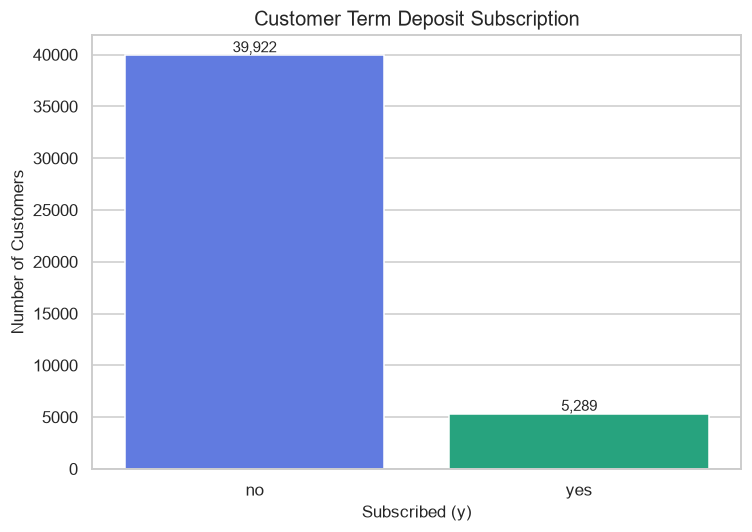

Total customers: 45,211
Subscribed (yes): 5,289
Did not subscribe (no): 39,922
Overall subscription rate: 11.70%


In [6]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="y", hue="y", palette=["#4c6ef5", "#12b886"], legend=False)
plt.title("Customer Term Deposit Subscription")
plt.xlabel("Subscribed (y)")
plt.ylabel("Number of Customers")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

n_total = len(df)
n_yes = int((df["y"] == "yes").sum())
n_no = int((df["y"] == "no").sum())
subscription_rate = (n_yes / n_total) * 100

print(f"Total customers: {n_total:,}")
print(f"Subscribed (yes): {n_yes:,}")
print(f"Did not subscribe (no): {n_no:,}")
print(f"Overall subscription rate: {subscription_rate:.2f}%")


## Exploratory Data Analysis

The plots below explore how demographic and campaign features relate to term-deposit subscription. Rates are computed from the cleaned dataset.


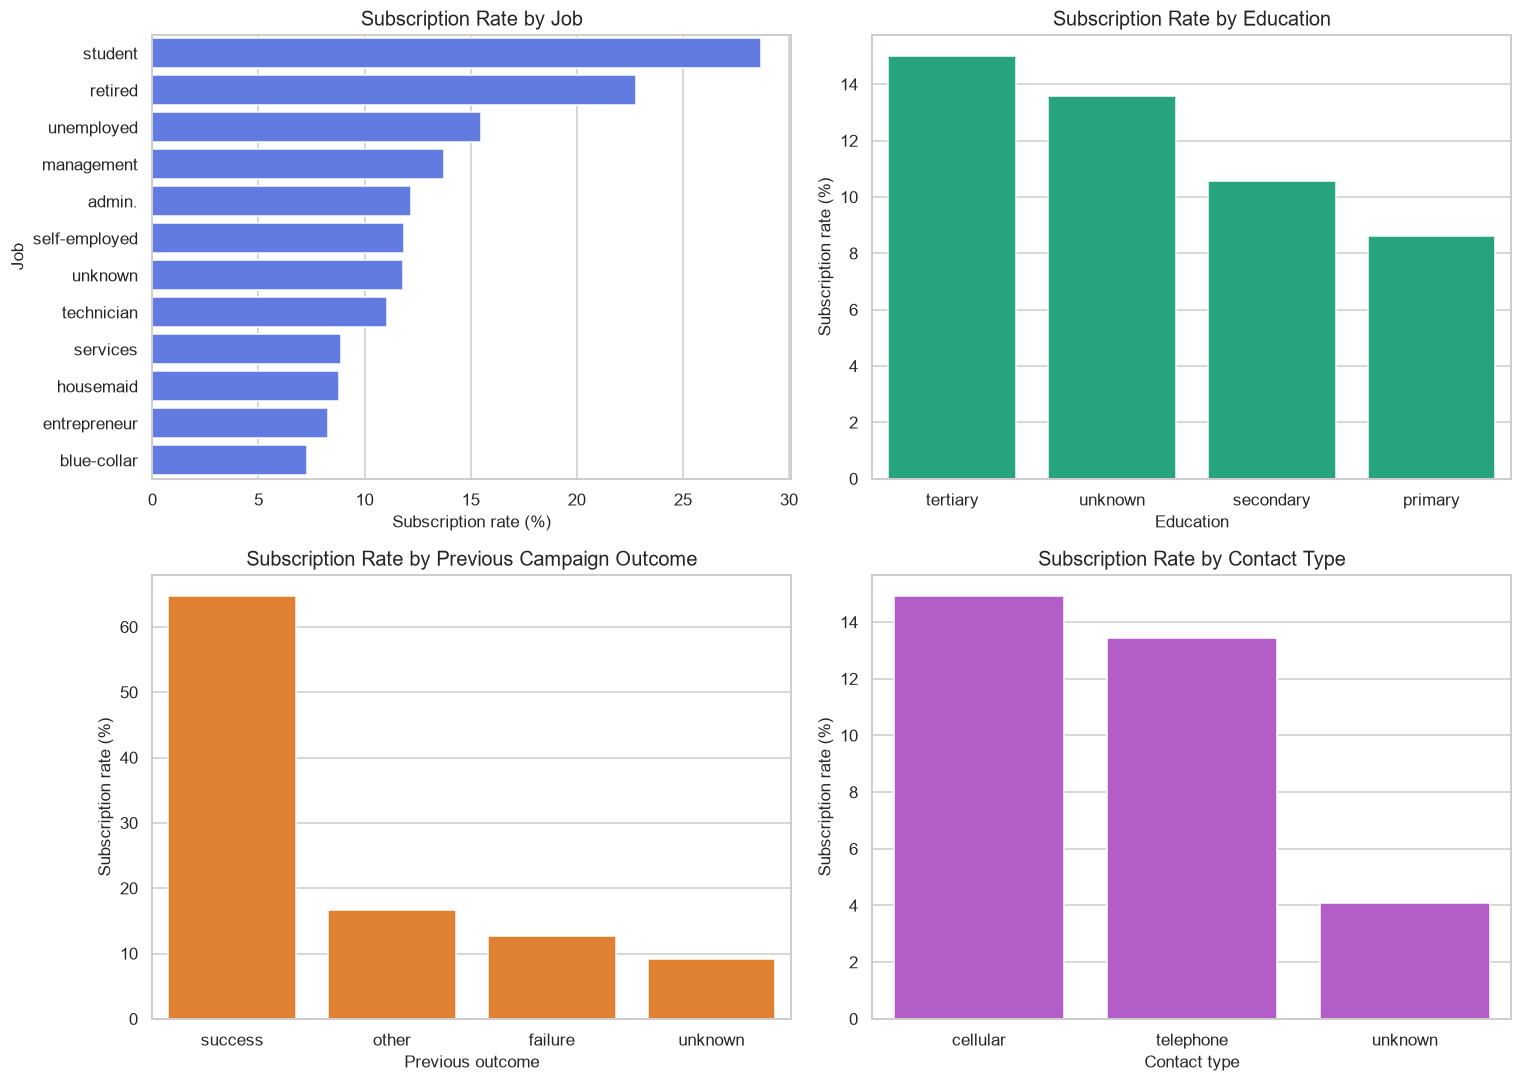

Subscription rate by job (%):


,subscription_rate_pct
job,
student,28.68
retired,22.79
unemployed,15.50
management,13.76
admin.,12.20
self-employed,11.84
unknown,11.81
technician,11.06
services,8.88



Subscription rate by previous outcome (%):


,subscription_rate_pct
poutcome,
success,64.73
other,16.68
failure,12.61
unknown,9.16


In [7]:
def subscription_rate_by(column: str) -> pd.Series:
    return (
        df.groupby(column)["y"]
        .apply(lambda s: (s == "yes").mean() * 100)
        .sort_values(ascending=False)
    )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

job_rate = subscription_rate_by("job")
sns.barplot(x=job_rate.values, y=job_rate.index, ax=axes[0, 0], color="#4c6ef5")
axes[0, 0].set_title("Subscription Rate by Job")
axes[0, 0].set_xlabel("Subscription rate (%)")
axes[0, 0].set_ylabel("Job")

edu_rate = subscription_rate_by("education")
sns.barplot(x=edu_rate.index, y=edu_rate.values, ax=axes[0, 1], color="#12b886")
axes[0, 1].set_title("Subscription Rate by Education")
axes[0, 1].set_xlabel("Education")
axes[0, 1].set_ylabel("Subscription rate (%)")

pout_rate = subscription_rate_by("poutcome")
sns.barplot(x=pout_rate.index, y=pout_rate.values, ax=axes[1, 0], color="#fd7e14")
axes[1, 0].set_title("Subscription Rate by Previous Campaign Outcome")
axes[1, 0].set_xlabel("Previous outcome")
axes[1, 0].set_ylabel("Subscription rate (%)")

contact_rate = subscription_rate_by("contact")
sns.barplot(x=contact_rate.index, y=contact_rate.values, ax=axes[1, 1], color="#be4bdb")
axes[1, 1].set_title("Subscription Rate by Contact Type")
axes[1, 1].set_xlabel("Contact type")
axes[1, 1].set_ylabel("Subscription rate (%)")

plt.tight_layout()
plt.show()

print("Subscription rate by job (%):")
display(job_rate.round(2).to_frame("subscription_rate_pct"))
print("\nSubscription rate by previous outcome (%):")
display(pout_rate.round(2).to_frame("subscription_rate_pct"))


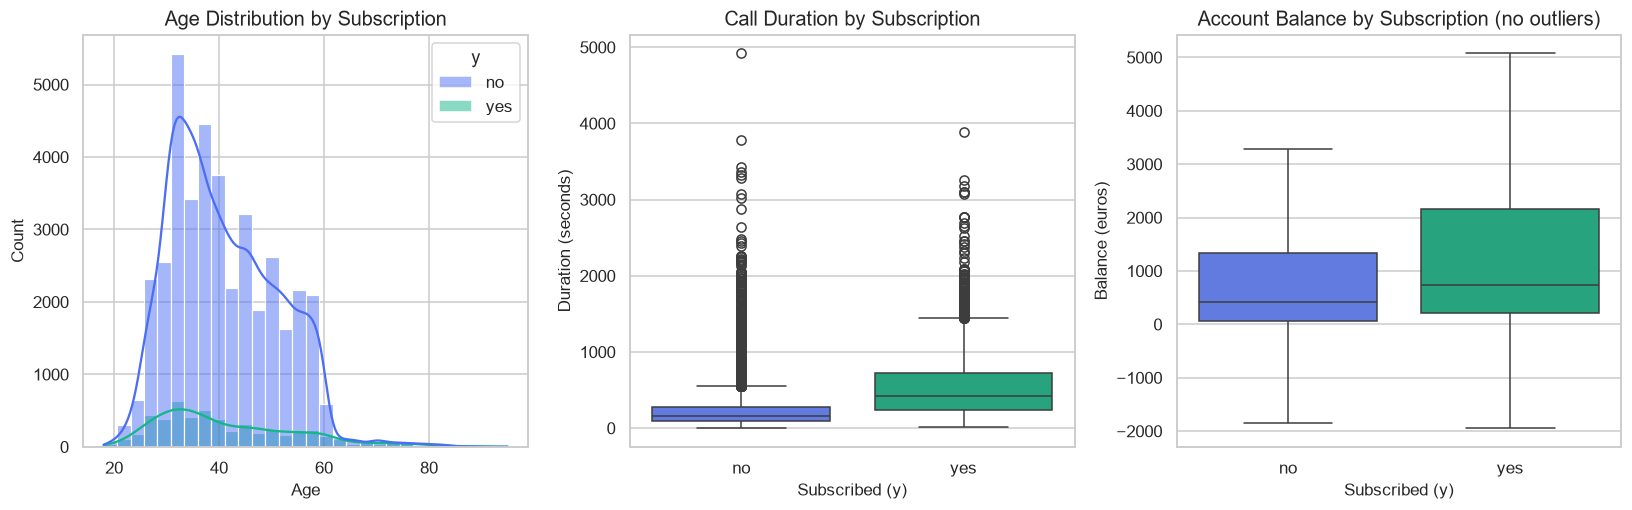

Mean call duration by subscription:


,mean_duration_seconds
y,
no,221.18
yes,537.29



Median account balance by subscription:


,median_balance
y,
no,417.0
yes,733.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sns.histplot(data=df, x="age", hue="y", bins=30, kde=True, ax=axes[0], palette=["#4c6ef5", "#12b886"])
axes[0].set_title("Age Distribution by Subscription")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, x="y", y="duration", hue="y", palette=["#4c6ef5", "#12b886"], legend=False, ax=axes[1])
axes[1].set_title("Call Duration by Subscription")
axes[1].set_xlabel("Subscribed (y)")
axes[1].set_ylabel("Duration (seconds)")

sns.boxplot(data=df, x="y", y="balance", hue="y", palette=["#4c6ef5", "#12b886"], legend=False, ax=axes[2], showfliers=False)
axes[2].set_title("Account Balance by Subscription (no outliers)")
axes[2].set_xlabel("Subscribed (y)")
axes[2].set_ylabel("Balance (euros)")

plt.tight_layout()
plt.show()

print("Mean call duration by subscription:")
display(df.groupby("y")["duration"].mean().round(2).to_frame("mean_duration_seconds"))
print("\nMedian account balance by subscription:")
display(df.groupby("y")["balance"].median().round(2).to_frame("median_balance"))


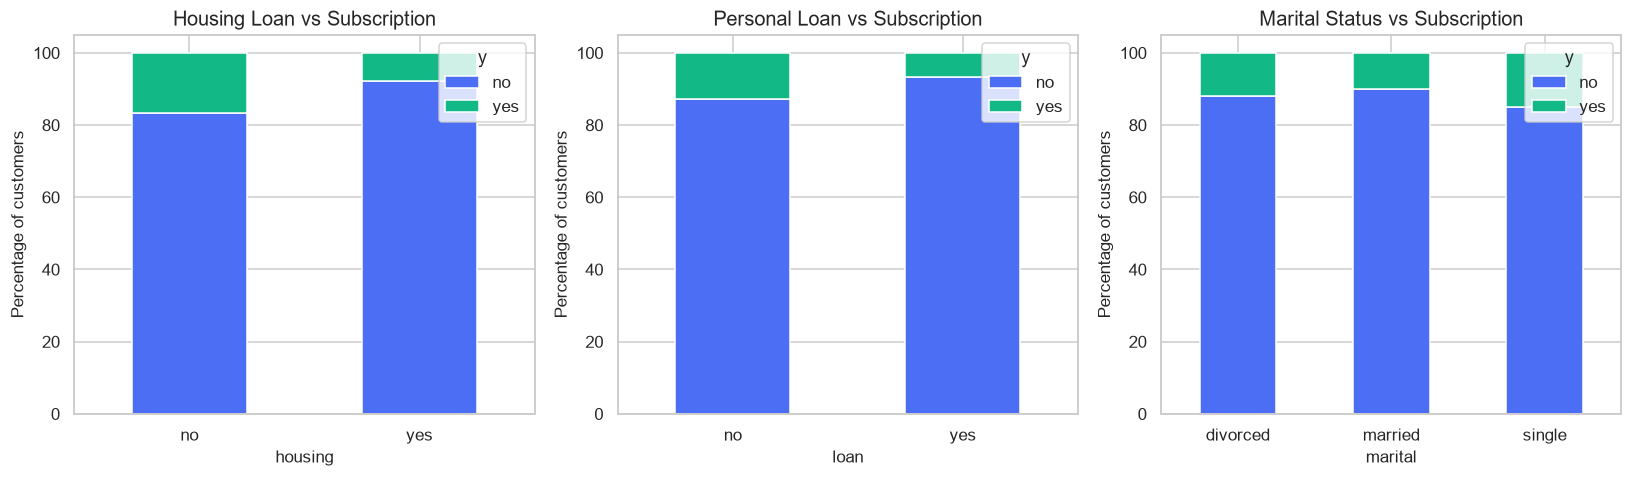

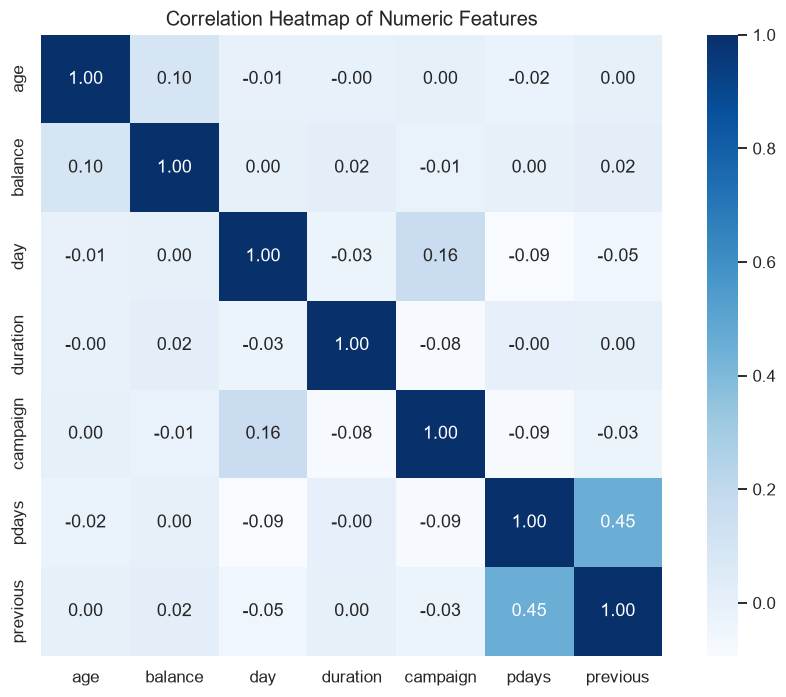

Stacked subscription mix plotted for housing, loan, and marital status.
Numeric-feature correlation heatmap plotted.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title in zip(
    axes,
    ["housing", "loan", "marital"],
    ["Housing Loan vs Subscription", "Personal Loan vs Subscription", "Marital Status vs Subscription"],
):
    ct = pd.crosstab(df[col], df["y"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#4c6ef5", "#12b886"], rot=0)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Percentage of customers")
    ax.legend(title="y", loc="upper right")

plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

print("Stacked subscription mix plotted for housing, loan, and marital status.")
print("Numeric-feature correlation heatmap plotted.")


## 6. Prepare Features and Target

The target is mapped to integers so scikit-learn can train the classifier:

- `"no"` → `0` (no subscription)
- `"yes"` → `1` (subscription)

Categorical and numeric feature lists are identified automatically from the column dtypes.


In [10]:
X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget value counts after encoding:")
display(y.value_counts().rename({0: "No Subscription (0)", 1: "Subscription (1)"}))

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)


Feature matrix shape: (45211, 16)
Target vector shape: (45211,)

Target value counts after encoding:


y
No Subscription (0)    39922
Subscription (1)        5289
Name: count, dtype: int64


Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6704\2182477325.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


## 7. Train–Test Split

The data is split into 80% training and 20% testing.

`stratify=y` keeps the same subscription / non-subscription ratio in both sets, which is important because the classes are imbalanced.

`random_state=42` makes the split reproducible.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])
print("\nTraining target distribution (%):")
display((y_train.value_counts(normalize=True) * 100).round(2).rename({0: "No Subscription", 1: "Subscription"}))
print("\nTesting target distribution (%):")
display((y_test.value_counts(normalize=True) * 100).round(2).rename({0: "No Subscription", 1: "Subscription"}))


Number of training samples: 36168
Number of testing samples: 9043

Training target distribution (%):


y
No Subscription    88.3
Subscription       11.7
Name: proportion, dtype: float64


Testing target distribution (%):


y
No Subscription    88.3
Subscription       11.7
Name: proportion, dtype: float64

## 8. Categorical Encoding

Categorical columns are one-hot encoded with `OneHotEncoder(handle_unknown="ignore")`. Numeric columns are passed through unchanged.

A `ColumnTransformer` keeps this step inside the model pipeline so encoding is fitted **only on the training data** and then applied to the test data. That avoids data leakage.


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
        (
            "num",
            "passthrough",
            numerical_features,
        ),
    ]
)

print("Preprocessor created.")
print("Categorical columns will be one-hot encoded.")
print("Numerical columns will be passed through unchanged.")


Preprocessor created.
Categorical columns will be one-hot encoded.
Numerical columns will be passed through unchanged.


## 9. Build Decision Tree Classifier

The classifier is wrapped in a scikit-learn `Pipeline` together with the preprocessor.

Tree complexity is limited so the model stays readable and is less likely to overfit:

| Parameter | Value | Reason |
| --- | --- | --- |
| `criterion` | `gini` | Standard impurity measure for classification trees |
| `max_depth` | `6` | Caps tree growth for a compact, interpretable model |
| `min_samples_split` | `20` | A node must have at least 20 samples before it can split |
| `min_samples_leaf` | `10` | Each leaf must contain at least 10 samples |
| `random_state` | `42` | Reproducible splits |
| `class_weight` | `balanced` | Up-weights the minority (subscriber) class |


In [13]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=6,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

print("Decision Tree pipeline created.")
display(model)


Decision Tree pipeline created.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 10. Train Model

The pipeline is fitted on the training set. Fitting trains both the one-hot encoder and the decision tree.


In [14]:
model.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")


Decision Tree Classifier trained successfully.


## 11. Predictions

Predicted class labels are generated for the held-out test set.


In [15]:
y_pred = model.predict(X_test)

print("Predictions generated for the test set.")
print("Number of predictions:", len(y_pred))
print("Predicted class counts:")
display(pd.Series(y_pred).value_counts().rename({0: "Predicted No Subscription", 1: "Predicted Subscription"}))


Predictions generated for the test set.
Number of predictions: 9043
Predicted class counts:


Predicted No Subscription    6440
Predicted Subscription       2603
Name: count, dtype: int64

## 12. Model Evaluation

Accuracy, precision, recall, and F1-score are computed on the test set. Because the classes are imbalanced, accuracy alone is not enough — recall and F1 for the subscriber class matter for a marketing-targeting use case.


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Accuracy (raw): {accuracy:.4f}")
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Subscription", "Subscription"],
    )
)


Accuracy: 79.55%
Accuracy (raw): 0.7955

Classification Report:
                 precision    recall  f1-score   support

No Subscription       0.98      0.79      0.87      7985
   Subscription       0.35      0.86      0.49      1058

       accuracy                           0.80      9043
      macro avg       0.66      0.82      0.68      9043
   weighted avg       0.90      0.80      0.83      9043



## 13. Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified.

- **True Negative (Actual No, Predicted No):** correctly identified non-subscribers
- **False Positive (Actual No, Predicted Yes):** non-subscribers predicted as subscribers
- **False Negative (Actual Yes, Predicted No):** subscribers the model missed
- **True Positive (Actual Yes, Predicted Yes):** correctly identified subscribers


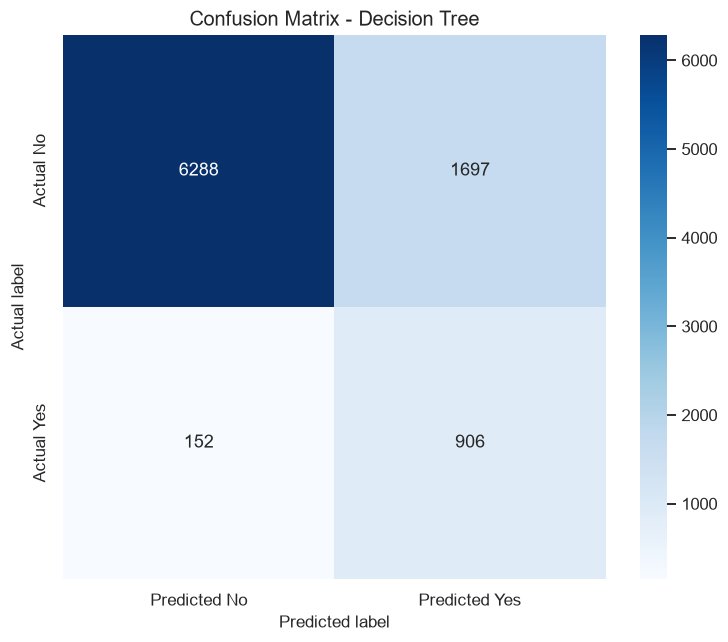

Confusion matrix values:
True Negatives  (Actual No,  Predicted No):  6288
False Positives (Actual No,  Predicted Yes): 1697
False Negatives (Actual Yes, Predicted No):  152
True Positives  (Actual Yes, Predicted Yes): 906


In [17]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"],
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

print("Confusion matrix values:")
print(f"True Negatives  (Actual No,  Predicted No):  {tn}")
print(f"False Positives (Actual No,  Predicted Yes): {fp}")
print(f"False Negatives (Actual Yes, Predicted No):  {fn}")
print(f"True Positives  (Actual Yes, Predicted Yes): {tp}")


## 14. Decision Tree Visualization

The trained tree is extracted from the pipeline and plotted. Only the **first three levels** are drawn so the diagram stays readable. Each node shows the split feature, the Gini impurity, the sample count, and the majority class.


Number of features after encoding: 51
Tree depth: 6
Number of leaves: 61


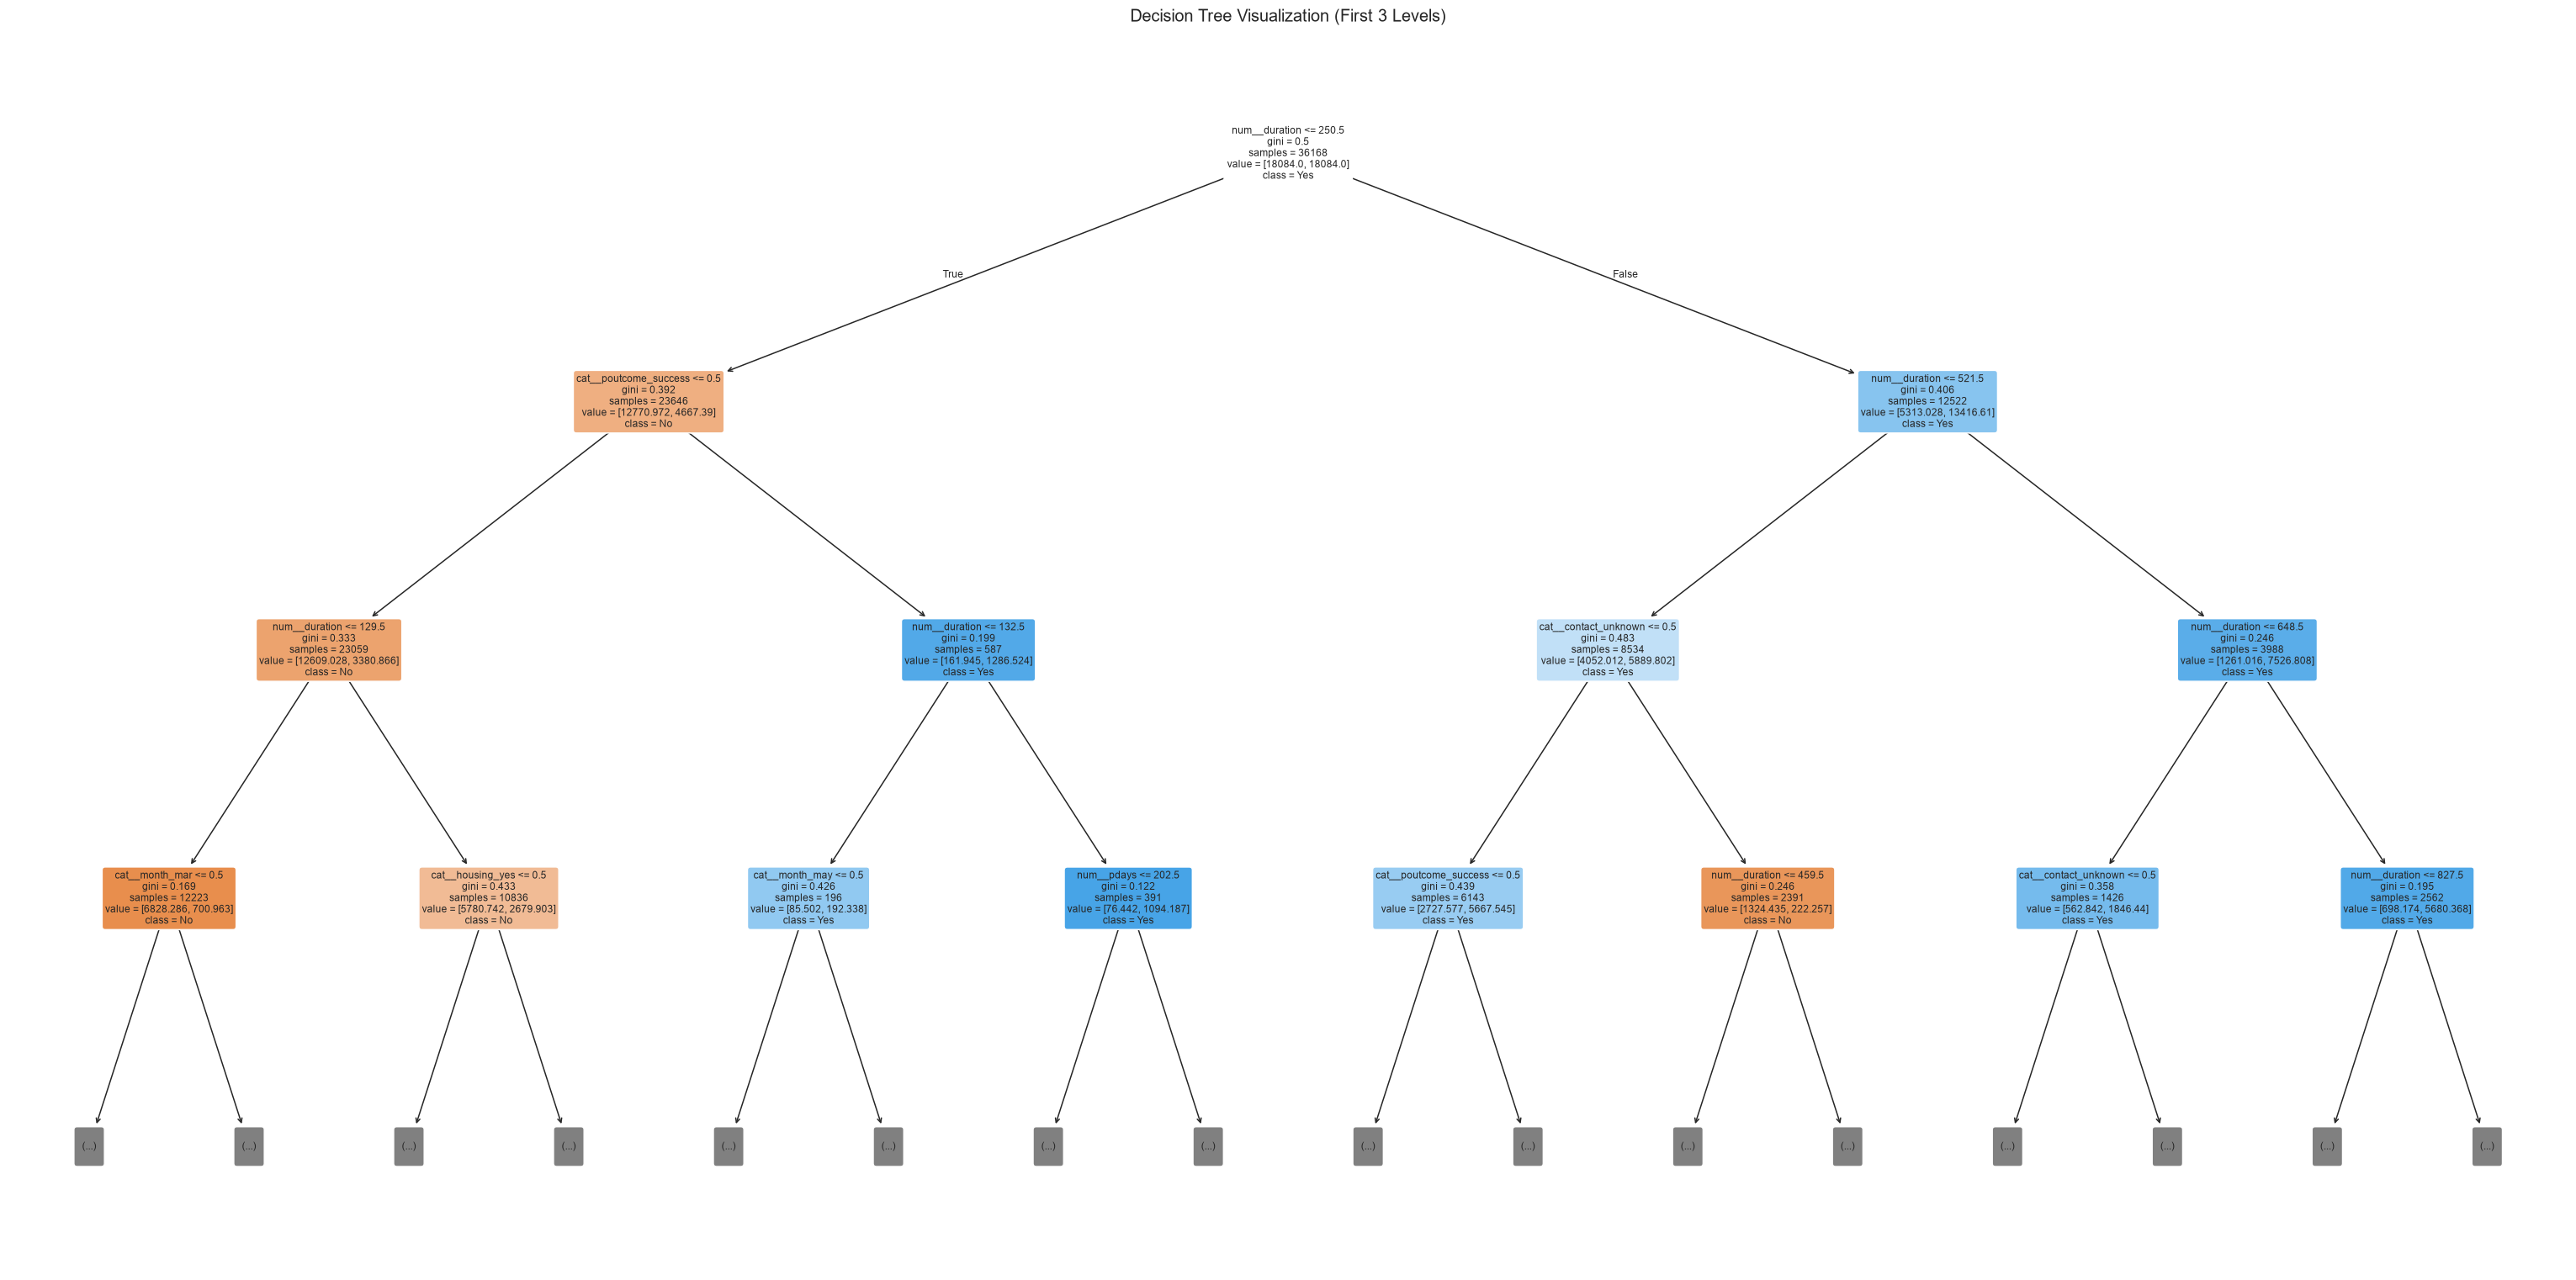

In [18]:
tree_model = model.named_steps["classifier"]
fitted_preprocessor = model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of features after encoding:", len(feature_names))
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

plt.figure(figsize=(28, 14))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.tight_layout()
plt.show()


## 15. Feature Importance

Gini importance measures how much each encoded feature reduced impurity across the tree. The values are taken directly from the trained `DecisionTreeClassifier`.


Top 15 Feature Importances:


,importance
num__duration,0.547212
cat__poutcome_success,0.171527
cat__contact_unknown,0.109296
cat__housing_yes,0.071634
cat__month_mar,0.019324
cat__month_oct,0.019001
cat__month_aug,0.017675
cat__loan_no,0.010631
num__pdays,0.007851
cat__month_feb,0.005898


num__duration            0.5472
cat__poutcome_success    0.1715
cat__contact_unknown     0.1093
cat__housing_yes         0.0716
cat__month_mar           0.0193
cat__month_oct           0.0190
cat__month_aug           0.0177
cat__loan_no             0.0106
num__pdays               0.0079
cat__month_feb           0.0059
cat__month_may           0.0053
cat__month_jun           0.0032
num__age                 0.0029
num__balance             0.0018
cat__month_jan           0.0016


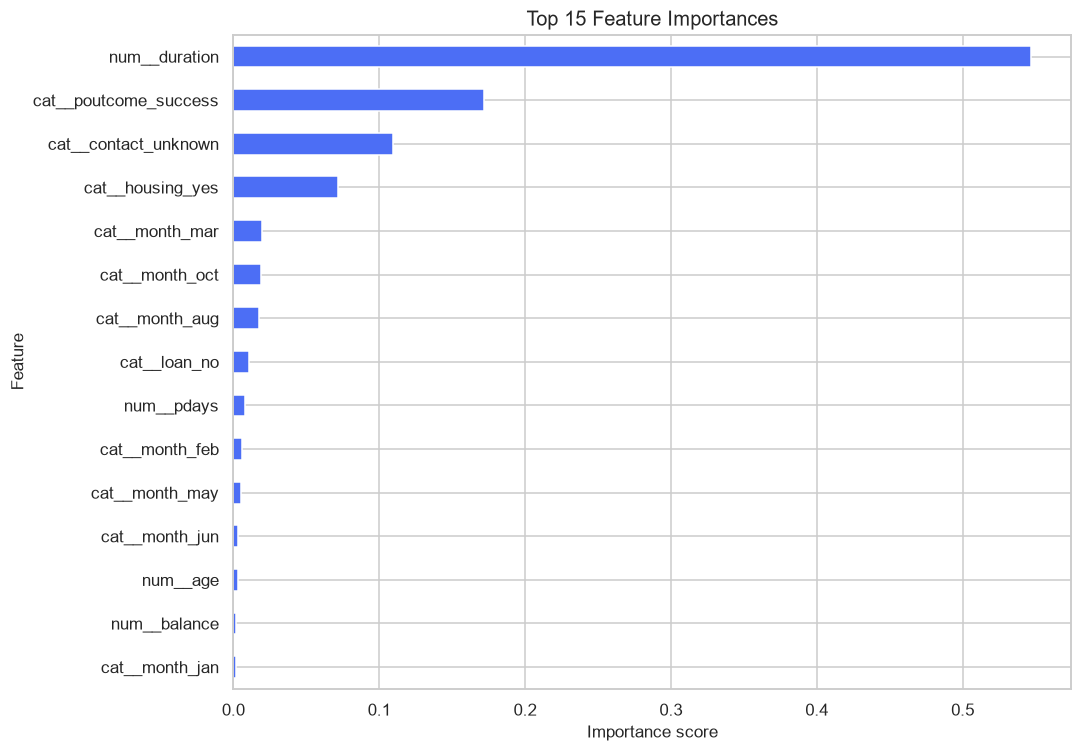

In [19]:
importances = pd.Series(tree_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

print("Top 15 Feature Importances:")
top15 = importances.head(15)
display(top15.to_frame("importance"))
print(top15.round(4).to_string())

plt.figure(figsize=(10, 7))
top15.sort_values(ascending=True).plot(kind="barh", color="#4c6ef5")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Key Findings

The numbered points below are produced by the following code cell from the **actual fitted model and test-set metrics**. They are not hard-coded in advance.


In [20]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["No Subscription", "Subscription"],
    output_dict=True,
)

prec_no = report["No Subscription"]["precision"]
rec_no = report["No Subscription"]["recall"]
f1_no = report["No Subscription"]["f1-score"]
prec_yes = report["Subscription"]["precision"]
rec_yes = report["Subscription"]["recall"]
f1_yes = report["Subscription"]["f1-score"]

print("=" * 72)
print("KEY FINDINGS (computed from this notebook run)")
print("=" * 72)

print("\n1. Overall subscription behaviour")
print(f"   - The cleaned dataset contains {n_total:,} customers and {df.shape[1]} columns.")
print(f"   - {n_yes:,} customers subscribed ({subscription_rate:.2f}%).")
print(f"   - {n_no:,} customers did not subscribe ({100 - subscription_rate:.2f}%).")
print("   - The target is imbalanced: non-subscribers are the majority class.")

print("\n2. Model performance")
print(f"   - Test accuracy: {accuracy * 100:.2f}%")
print(f"   - No Subscription  | precision={prec_no:.3f}, recall={rec_no:.3f}, F1={f1_no:.3f}")
print(f"   - Subscription     | precision={prec_yes:.3f}, recall={rec_yes:.3f}, F1={f1_yes:.3f}")
print("   - class_weight='balanced' trades some precision on subscribers for higher recall,")
print("     which is useful when the business cost of missing a likely subscriber is high.")

print("\n3. Confusion matrix interpretation")
print(f"   - True Negatives:  {tn:,}  (correctly predicted non-subscribers)")
print(f"   - False Positives: {fp:,}  (non-subscribers predicted as subscribers)")
print(f"   - False Negatives: {fn:,}  (subscribers the model missed)")
print(f"   - True Positives:  {tp:,}  (correctly predicted subscribers)")
print(f"   - Of all actual subscribers in the test set, {tp:,} were found and {fn:,} were missed.")

print("\n4. Important features")
print("   The tree relied most on:")
for i, (name, value) in enumerate(top15.head(8).items(), start=1):
    print(f"   {i}. {name:40s}  importance = {value:.4f}")

print("\n5. Relationship between customer / marketing variables and subscription")
print("   - Call duration is typically the strongest split: longer conversations are")
print("     associated with a higher chance of subscription. This feature is measured")
print("     during the call, so it is very predictive but not available for pre-call targeting.")
print("   - A successful previous campaign outcome (poutcome) is a strong positive signal.")
print("   - Contact channel, month, age, and account balance also contribute to the splits.")
print("   - Students and retired customers showed higher raw subscription rates in the EDA,")
print("     while customers with housing or personal loans subscribed less often.")
print("=" * 72)


KEY FINDINGS (computed from this notebook run)

1. Overall subscription behaviour
   - The cleaned dataset contains 45,211 customers and 17 columns.
   - 5,289 customers subscribed (11.70%).
   - 39,922 customers did not subscribe (88.30%).
   - The target is imbalanced: non-subscribers are the majority class.

2. Model performance
   - Test accuracy: 79.55%
   - No Subscription  | precision=0.976, recall=0.787, F1=0.872
   - Subscription     | precision=0.348, recall=0.856, F1=0.495
   - class_weight='balanced' trades some precision on subscribers for higher recall,
     which is useful when the business cost of missing a likely subscriber is high.

3. Confusion matrix interpretation
   - True Negatives:  6,288  (correctly predicted non-subscribers)
   - False Positives: 1,697  (non-subscribers predicted as subscribers)
   - False Negatives: 152  (subscribers the model missed)
   - True Positives:  906  (correctly predicted subscribers)
   - Of all actual subscribers in the test set, 

### How to read these findings

- **Class imbalance.** Most customers do not subscribe. A model that always predicted `"no"` would look accurate but would be useless for marketing. That is why precision, recall, F1, and the confusion matrix are reported alongside accuracy, and why `class_weight="balanced"` was used.
- **Duration caveat.** `duration` (last-call length in seconds) is a powerful predictor, but it is only known *after* the call has happened. For a production system that ranks customers *before* calling them, this feature should be excluded and the tree retrained. It is kept here because the internship task uses the full Bank Marketing feature set.
- **Campaign history.** Customers with a previous successful outcome convert at a much higher rate. Re-contacting past successes is a practical targeting rule that the tree rediscovers.
- **Demographics.** Age, job, education, and loan status interact with campaign variables. The tree uses these jointly rather than as isolated rules.


## Conclusion

A Decision Tree Classifier was successfully built to predict whether a bank customer will subscribe to a term deposit.

The Bank Marketing dataset from the UCI Machine Learning Repository (provided as Prodigy InfoTech Task 03) was loaded, inspected, and cleaned. Duplicate rows were removed. Recorded `"unknown"` values were retained as valid categories rather than being treated as missing data.

Categorical variables were encoded with one-hot encoding inside a scikit-learn `ColumnTransformer`, and numeric variables were passed through unchanged. The full preprocessing-plus-model workflow was stored in a single `Pipeline`, which keeps encoding fitted on the training set only.

The data was split into training (80%) and testing (20%) sets with stratification so that the original class balance was preserved. The decision tree was trained with a controlled depth and balanced class weights to remain interpretable and to pay attention to the minority subscriber class.

Model quality was assessed with accuracy, a full classification report (precision, recall, F1-score, support), and a confusion matrix. The first three levels of the fitted tree were visualised, and Gini feature importances were extracted to identify the variables that most influenced the subscription prediction.

Overall, the project demonstrates a complete, reproducible supervised-learning workflow — from data loading through evaluation — and shows how a decision tree can turn demographic and behavioural marketing data into an interpretable purchase / subscription classifier.

---

**Submitted by:** Asif Ansari  
**Internship:** Prodigy InfoTech – Data Science  
**Task:** 03 – Decision Tree Classifier  
**Dataset:** Bank Marketing (`bank-full.csv`)
